In [2]:
test_cases = [
    {"probs": [0.5] * 100,"title": "Binomial(n=100, p=0.5)"},
    {"probs": [0.1] * 50 + [0.9] * 30 + [0.4] * 20,"title": "Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)"},
    {"probs": ([0.02] * 20 + [0.03] * 20 + [0.98] * 20 + [0.97] * 20 + [0.01] * 10 + [0.99] * 10),"title": "Many near-extreme probabilities (n=100)"},
    {"probs": [0.1] * 10 + [0.2] * 10 + [0.3] * 10 + [0.4] * 10 + [0.5] * 10 + [0.6] * 10 + [0.7] * 10 + [0.8] * 10 + [0.9] * 10,"title": "Heterogeneous [0.1,0.2,...,0.9] ×10 (n=90)"},
    {"probs": [0] * 100, "title": "All zero probabilities (n=100)"},
    {"probs": [1] * 100, "title": "All one probabilities (n=100)"},
]

# pmf

## Exact

In [3]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_pmf_exact(probs, device='cpu'):
    """
    Compute Poisson Binomial PMF using DFT/FFT method.
    Returns tensor of shape (n+1,) with P(S=k) for k=0..n
    """
    if not isinstance(probs, torch.Tensor):
        probs = torch.tensor(probs, dtype=torch.float64)
    probs = probs.to(device)
    
    if probs.dim() == 0:
        probs = probs.unsqueeze(0)
    
    n = probs.shape[-1]
    N = n + 1
    
    real_dtype = probs.dtype
    complex_dtype = torch.complex128 if real_dtype == torch.float64 else torch.complex64
    
    j = torch.arange(N, device=device, dtype=real_dtype)
    omega = torch.exp(2j * math.pi * j / N)
    
    cf = torch.ones((N,), dtype=complex_dtype, device=device)
    
    for i in range(n):
        p_i = probs[i].unsqueeze(-1)  # shape (1,)
        term = (1 - p_i) + p_i * omega
        cf = cf * term
    
    pmf = torch.fft.fft(cf, dim=-1).real / N
    pmf = pmf.clamp_(min=0.0)
    
    # Normalize (helps with float precision on larger n)
    total = pmf.sum()
    if total > 0:
        pmf /= total
    
    return pmf.cpu()

c:\Users\matth\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


## Approx

In [4]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_pmf_approx(probs, device='cpu'):
    """
    Approximate the Poisson Binomial PMF using the Refined Normal Approximation (RNA).
    Returns tensor of shape (n+1,) approximating P(S = k) for k = 0..n
    
    This is very fast (O(n)) but is an approximation — most accurate when n is large
    and probabilities are not too close to 0 or 1 for most trials.
    
    Based on Hong (2013) / Volkova (1996) refinement:
    Uses normal + skewness correction via Edgeworth-type expansion.
    """
    if not isinstance(probs, torch.Tensor):
        probs = torch.tensor(probs, dtype=torch.float64)
    
    probs = probs.to(device).flatten()   # ensure 1D
    n = probs.numel()

    if n == 0:
        return torch.tensor([1.0], device=device)
    
    # Mean (μ)
    mu = probs.sum()
    
    # Variance (σ²)
    var = probs.mul(1 - probs).sum()
    
    if var <= 1e-12:
        # Degenerate case: all p=0 or all p=1
        pmf = torch.zeros(n + 1, device=device, dtype=torch.float64)
        pmf[round(mu.item())] = 1.0
        return pmf.clamp_(min=0)
    
    sigma = torch.sqrt(var)
    
    mu3 = probs.mul(1 - probs).mul(1 - 2 * probs).sum()

    # Standardized skewness
    skew = mu3 / (sigma ** 3)                  # γ₁ = μ₃ / σ³

    # We will evaluate on integer grid k = 0,1,...,n
    k = torch.arange(n + 1, device=device, dtype=torch.float64)
    
    # Continuity correction: evaluate at k + 0.5
    z = (k - mu) / sigma
    
    # Standard normal pdf and cdf
    phi = torch.exp(-0.5 * z * z) / math.sqrt(2 * math.pi)          # pdf
    Phi = torch.distributions.Normal(0, 1).cdf(z)                   # cdf
    
    # RNA approximation to the CDF (cumulative)
    # F(k) ≈ Φ(z) + (γ / 6) * (1 - z²) * ϕ(z)
    correction = (skew / 6.0) * (z * z - 1.0) * phi
    pdf_approx = phi + correction
    
    pmf = pdf_approx.clamp_(min=0.0)

    # Normalize (very important — approximation is not guaranteed to integrate to 1)
    total = pmf.sum()
    if total > 1e-10:
        pmf.div_(total)

    return pmf.cpu()

## Plot

In [5]:
def plot_pmf(pmf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot PMF as bars + line+markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(pmf))
    p = pmf.numpy() if hasattr(pmf, 'numpy') else np.asarray(pmf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    mean = np.sum(k * p)
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
               label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

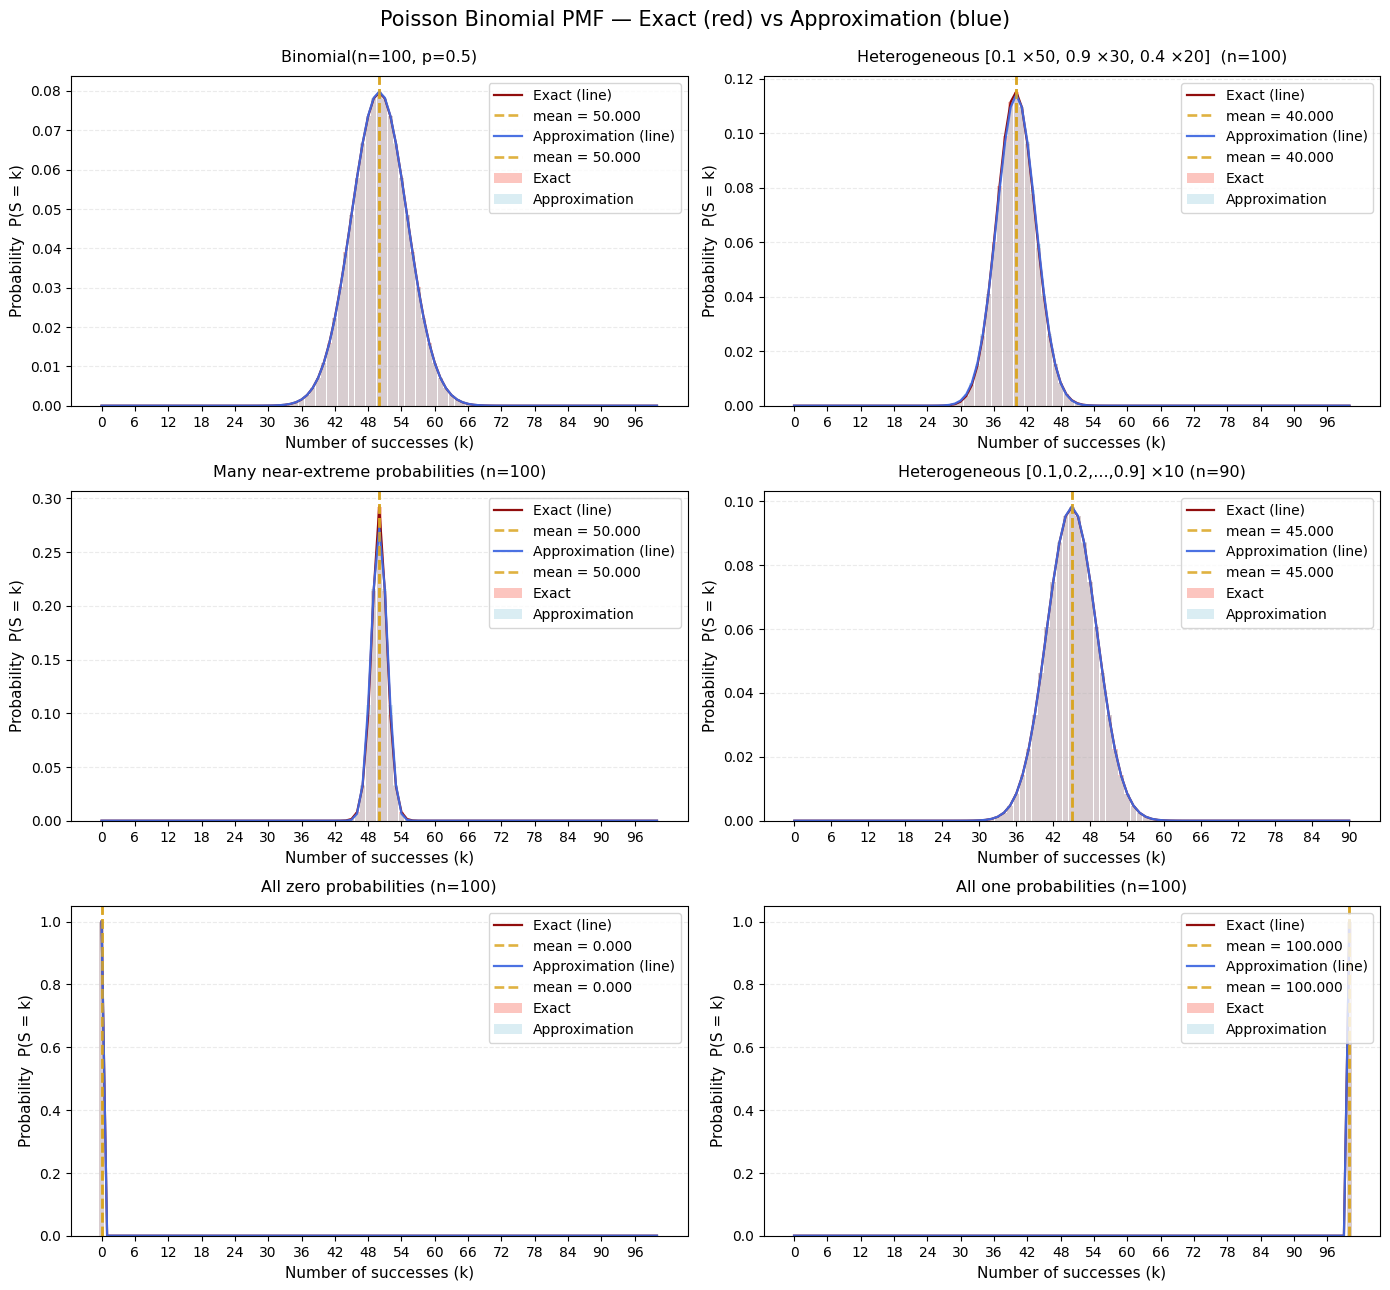

In [6]:
# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.2 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    plot_pmf(
        poisson_binomial_pmf_exact(case["probs"]),
        title=case["title"],
        ax=ax,
        is_exact=True
    )

    # Approximation → blue (overlaid)
    plot_pmf(
        poisson_binomial_pmf_approx(case["probs"]),
        title=case["title"],
        ax=ax,
        is_exact=False
    )

    # Optional: bigger/more visible title
    ax.set_title(f"{case['title']}", fontsize=11.5, pad=10)

# Hide empty subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle("Poisson Binomial PMF — Exact (red) vs Approximation (blue)", 
             fontsize=15, y=1.02)
plt.show()

# CDF

## Exact

In [7]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_cdf_exact(probs, value=None, device='cpu'):
    pmf = poisson_binomial_pmf_exact(probs, device=device)
    cdf_full = torch.cumsum(pmf, dim=-1)           # shape (n+1,)
    
    if value is None:
        return cdf_full
    
    # Evaluate at specific value(s)
    value = torch.as_tensor(value, dtype=torch.long, device=device)
    value = value.clamp_(min=0, max=len(pmf)-1)
    
    # Gather
    cdf_values = cdf_full[value]
    return cdf_values

## Approx

In [8]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_cdf_approx(probs, value=None, device='cpu'):
    """
    Mimic your .cdf() logic:
    Compute CDF = cumsum(pmf) over support 0,1,...,n
    If value is given → evaluate CDF at those points (batched possible)
    If value=None → return full CDF tensor (n+1,)
    """
    pmf = poisson_binomial_pmf_approx(probs, device=device)
    cdf_full = torch.cumsum(pmf, dim=-1)           # shape (n+1,)
    
    if value is None:
        return cdf_full
    
    # Evaluate at specific value(s)
    value = torch.as_tensor(value, dtype=torch.long, device=device)
    value = value.clamp_(min=0, max=len(pmf)-1)
    
    # Gather
    cdf_values = cdf_full[value]
    return cdf_values

## Plot

In [9]:
def plot_cdf(cdf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot CDF as line + markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(cdf))
    p = cdf.numpy() if hasattr(cdf, 'numpy') else np.asarray(cdf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    #mean = np.sum(k * p)
    #ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
    #           label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

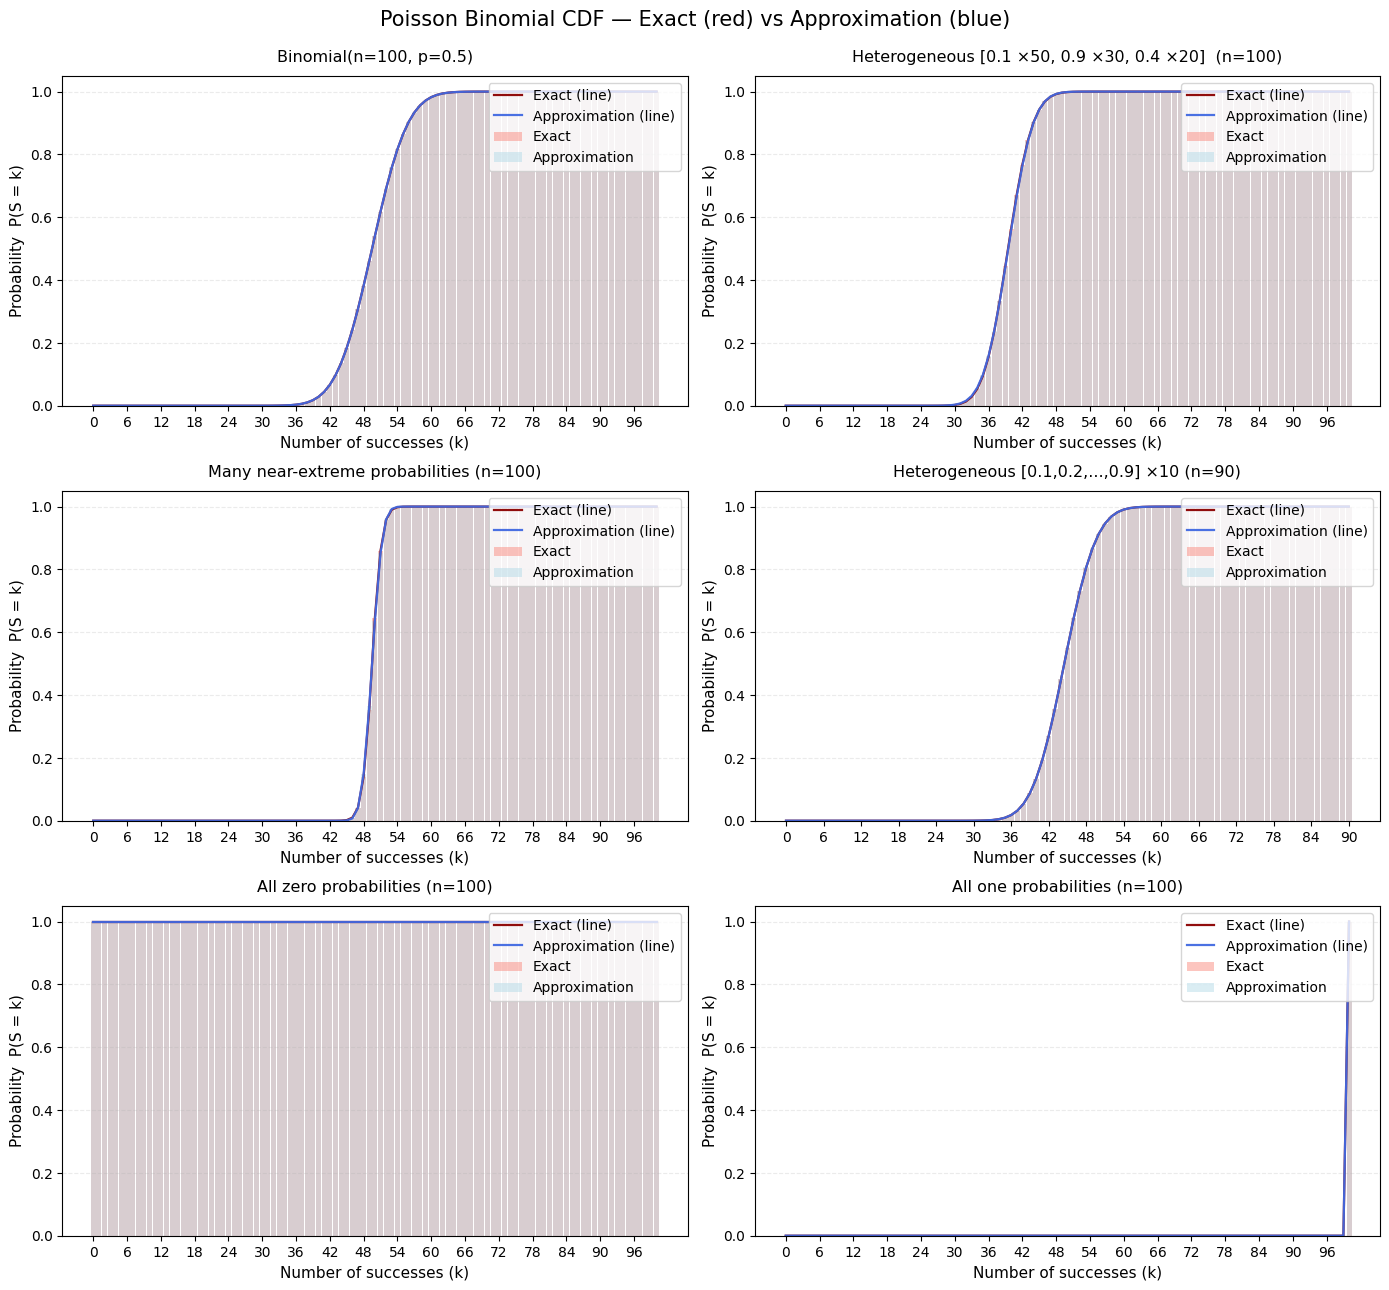

In [10]:
# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.2 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    plot_cdf(
        poisson_binomial_cdf_exact(case["probs"]),
        title=case["title"],
        ax=ax,
        is_exact=True
    )

    # Approximation → blue (overlaid)
    plot_cdf(
        poisson_binomial_cdf_approx(case["probs"]),
        title=case["title"],
        ax=ax,
        is_exact=False
    )

    # Optional: bigger/more visible title
    ax.set_title(f"{case['title']}", fontsize=11.5, pad=10)

# Hide empty subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle("Poisson Binomial CDF — Exact (red) vs Approximation (blue)", 
             fontsize=15, y=1.02)
plt.show()

# ICDF

## Exact

In [17]:
def poisson_binomial_icdf_exact(probs, value=None, device='cpu'):
    pmf = poisson_binomial_pmf_exact(probs, device=device)
    cdf_full = torch.cumsum(pmf, dim=-1)

    if value is None:
        return cdf_full
    
    value = torch.as_tensor(value, dtype=torch.float32, device=device)
    value = value.clamp_(min=0.0, max=1.0)
    
    icdf_values = torch.searchsorted(cdf_full, value)
    return icdf_values.cpu()

import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_icdf_exact(probs, value, device='cpu'):
    """
    Inverse CDF (quantile function) for Poisson Binomial distribution.
    Given q ∈ [0,1], returns smallest k such that CDF(k) ≥ q
    """
    if not isinstance(value, torch.Tensor):
        value = torch.tensor(value, dtype=torch.float64)
    value = value.to(device)

    if not torch.all((value >= 0) & (value <= 1)):
        raise ValueError("icdf input must be in [0,1]")

    if pmf is None:
        pmf = poisson_binomial_pmf_exact(probs, device=value.device)

    cdf = torch.cumsum(pmf, dim=-1)

    # Broadcasting: expand cdf to match value shape + support
    # value[..., None] vs cdf[None, ...]
    orig_ndim = value.ndim
    value = value[..., None]
    cdf = cdf[None, ...]   # at least 2D now

    # Find smallest k where cdf[k] >= value
    ge = cdf >= value
    k = ge.int().argmax(dim=-1)          # first True index

    # Edge case: if value > cdf[-1] → return n (but should be rare after clamp)
    k = k.clamp(max=cdf.shape[-1] - 1)

    if orig_ndim == 0 or (orig_ndim == 1 and value.shape[0] == 1):
        return k.squeeze()
    else:
        return k

## Approx

In [19]:
def poisson_binomial_icdf_approx(probs, value=None, device='cpu'):
    pmf = poisson_binomial_pmf_approx(probs, device=device)
    cdf_full = torch.cumsum(pmf, dim=-1)

    if value is None:
        return cdf_full
    
    value = torch.as_tensor(value, dtype=torch.float32, device=device)
    value = value.clamp_(min=0.0, max=1.0)
    
    icdf_values = torch.searchsorted(cdf_full, value)
    return icdf_values.cpu()

import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def poisson_binomial_icdf_approx(probs, value, pmf=None):
    """
    Inverse CDF (quantile function) for Poisson Binomial distribution.
    Given q ∈ [0,1], returns smallest k such that CDF(k) ≥ q
    """
    if not isinstance(value, torch.Tensor):
        value = torch.tensor(value, dtype=torch.float64)
    value = value.to(probs.device if isinstance(probs, torch.Tensor) else 'cpu')

    if not torch.all((value >= 0) & (value <= 1)):
        raise ValueError("icdf input must be in [0,1]")

    if pmf is None:
        pmf = poisson_binomial_pmf_approx(probs, device=value.device)

    cdf = torch.cumsum(pmf, dim=-1)

    # Broadcasting: expand cdf to match value shape + support
    # value[..., None] vs cdf[None, ...]
    orig_ndim = value.ndim
    value = value[..., None]
    cdf = cdf[None, ...]   # at least 2D now

    # Find smallest k where cdf[k] >= value
    ge = cdf >= value
    k = ge.int().argmax(dim=-1)          # first True index

    # Edge case: if value > cdf[-1] → return n (but should be rare after clamp)
    k = k.clamp(max=cdf.shape[-1] - 1)

    if orig_ndim == 0 or (orig_ndim == 1 and value.shape[0] == 1):
        return k.squeeze()
    else:
        return k

## Plot

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=250):
    """
    Plot the quantile function (inverse CDF) by evaluating at many points.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points in probability space
    q = np.linspace(0.001, 0.999, n_points)

    if is_exact:
        color = 'darkred'
        label = 'Exact quantile function'
        quantiles = []
        for qi in q:
            k = poisson_binomial_icdf_exact(probs, qi)
            quantiles.append(k.item() if torch.is_tensor(k) else k)
    else:
        color = 'royalblue'
        label = 'Approximate quantile function'
        quantiles = []
        for qi in q:
            k = poisson_binomial_icdf_approx(probs, qi)   # assuming you have this function
            quantiles.append(k.item() if torch.is_tensor(k) else k)

    quantiles = np.array(quantiles)

    # Plot
    ax.plot(q, quantiles, '-', color=color, lw=2.2, label=label)
    #ax.plot(q, quantiles, 'o', color=color, ms=4, alpha=0.6, markeredgecolor='none')

    ax.set_title(f"{title}\n({label})", fontsize=12, pad=10)
    ax.set_xlabel('Probability level q', fontsize=11)
    ax.set_ylabel('Smallest k s.t. P(S ≤ k) ≥ q', fontsize=11)
    ax.grid(True, alpha=0.25, ls='--')
    ax.legend(fontsize=10, loc='upper left')

    # Optional: step-like appearance (more accurate for discrete)
    # ax.step(q, quantiles, where='post', color=color, lw=2.2, label=label)

    return ax

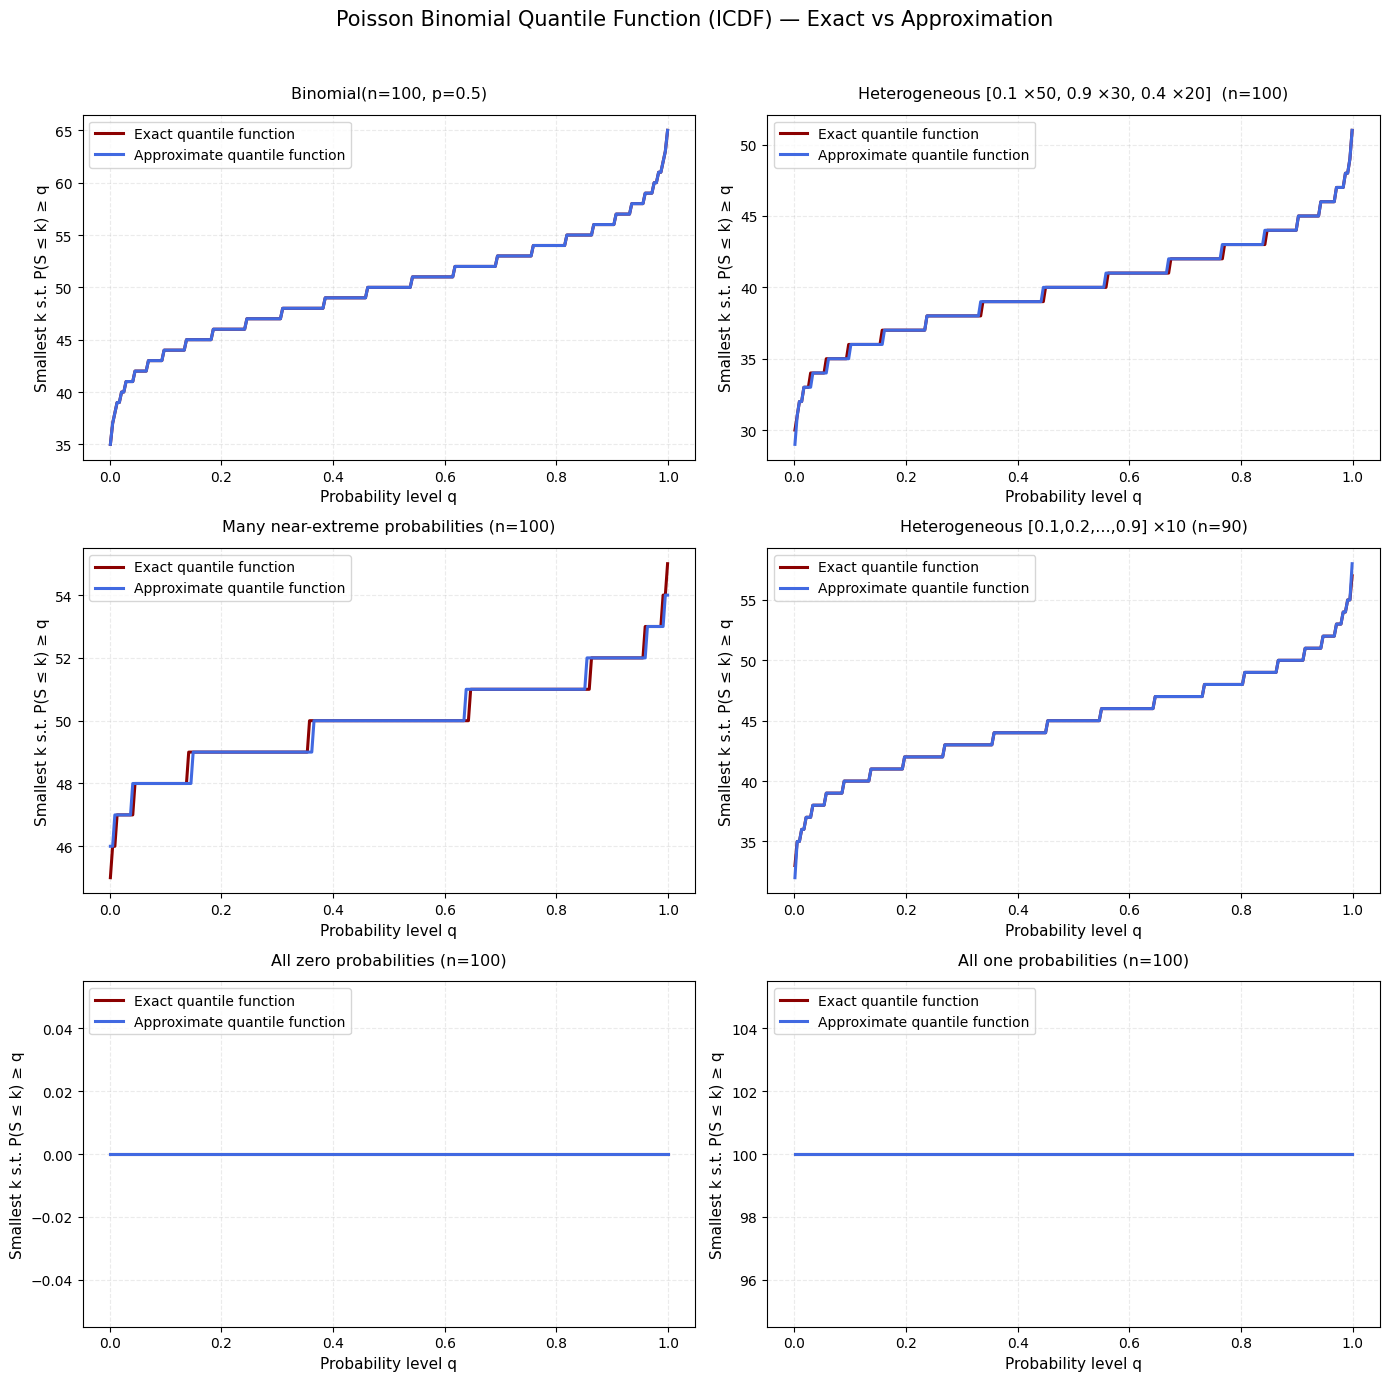

In [21]:

# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    plot_quantile_function(
        probs     = case["probs"],
        title     = case["title"],
        ax        = ax,
        is_exact  = True
    )

    # Approximation → blue (overlaid)
    plot_quantile_function(
        probs     = case["probs"],
        title     = case["title"],
        ax        = ax,
        is_exact  = False
    )

    ax.set_title(
        f"{case['title']}",
        fontsize=11.5,
        pad=12
    )

# Hide unused subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.suptitle("Poisson Binomial Quantile Function (ICDF) — Exact vs Approximation",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Entropy

## Exact

## Approx

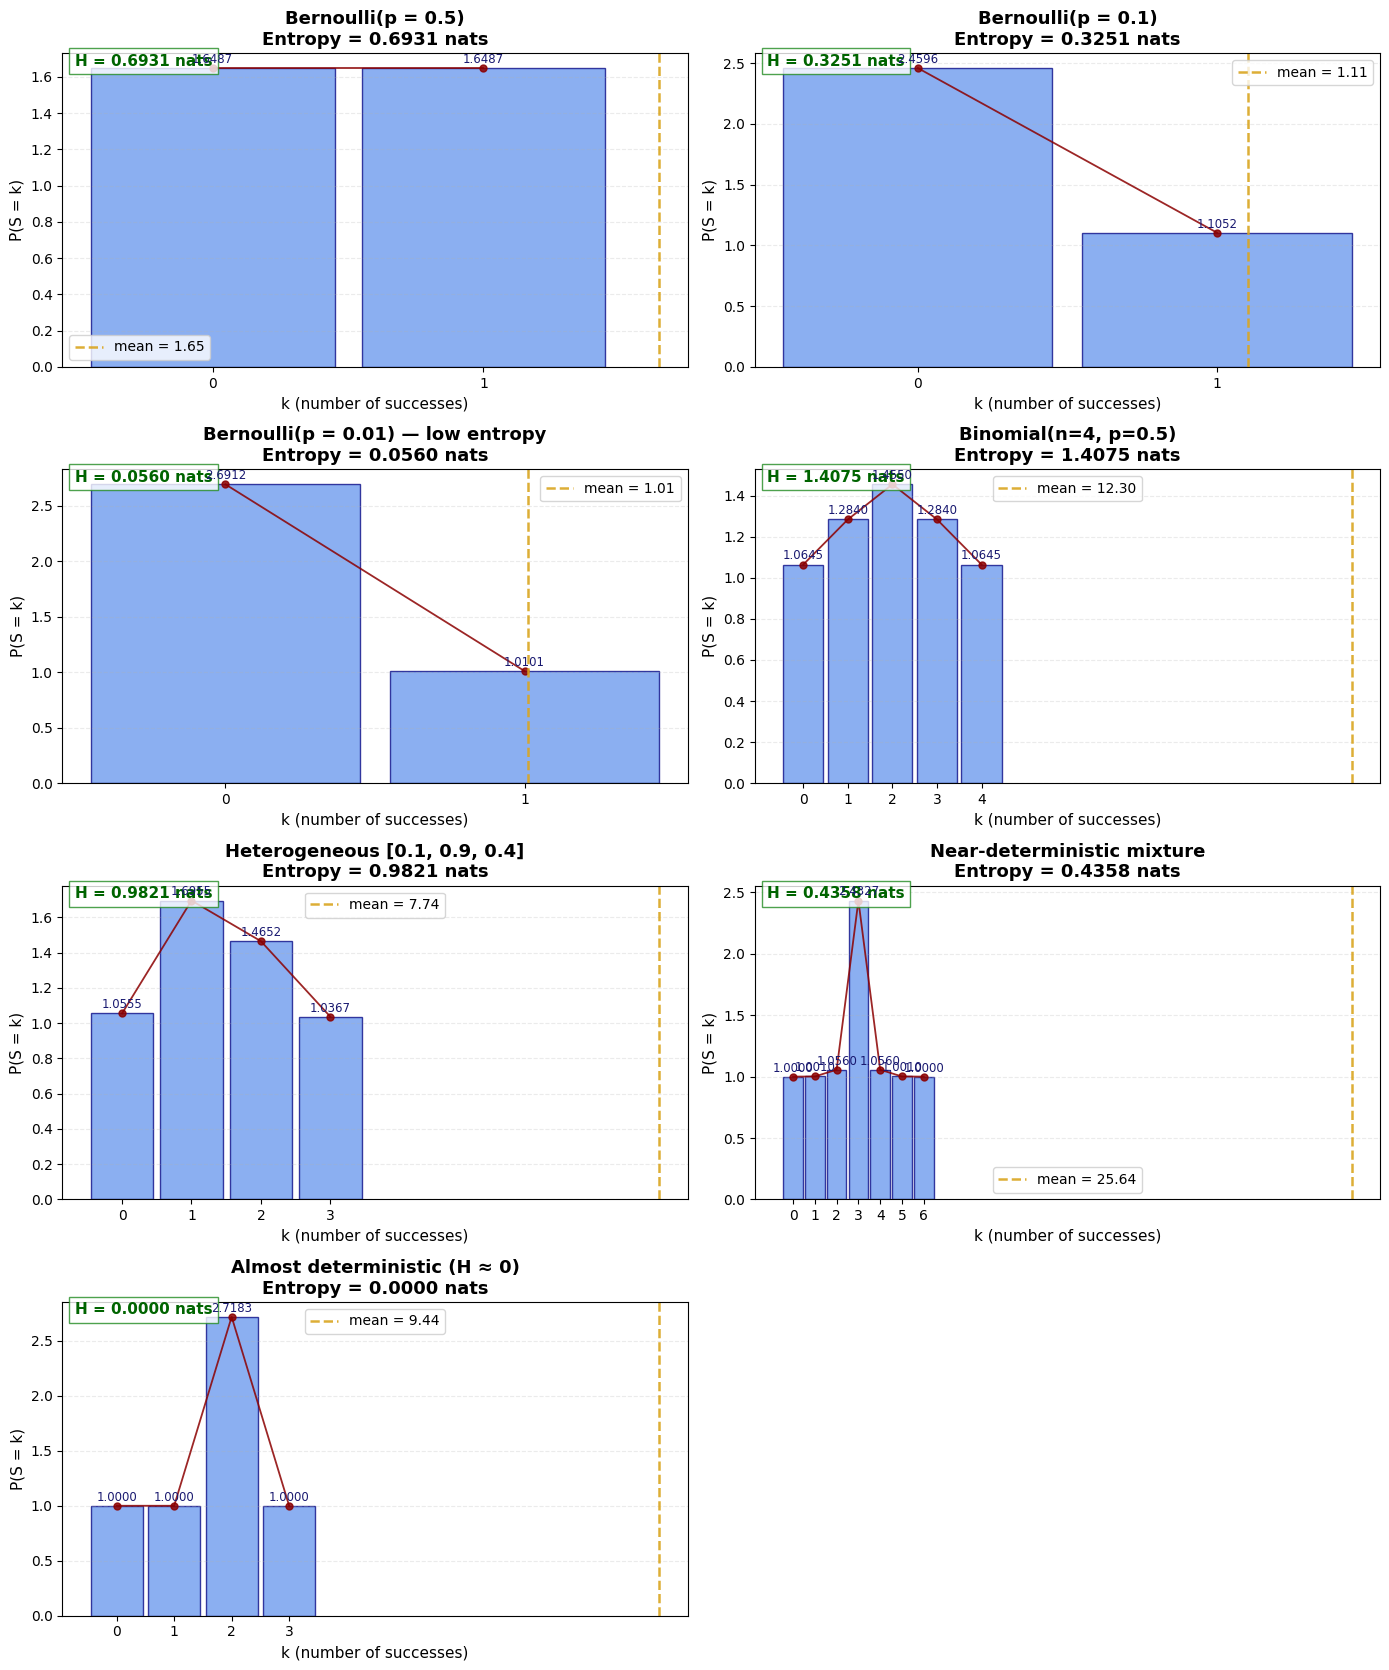


═════════════════════════════════════════════════════════════════
Entropy results (in nats — natural logarithm)
═════════════════════════════════════════════════════════════════
Case                                   Entropy (nats)  Max possible*
-----------------------------------------------------------------
Bernoulli(p = 0.5)                             0.6931         0.6931
Bernoulli(p = 0.1)                             0.3251         0.6931
Bernoulli(p = 0.01) — low entropy              0.0560         0.6931
Binomial(n=4, p=0.5)                           1.4075         1.6094
Heterogeneous [0.1, 0.9, 0.4]                  0.9821         1.3863
Near-deterministic mixture                     0.4358         1.9459
Almost deterministic (H ≈ 0)                   0.0000         1.3863
═════════════════════════════════════════════════════════════════
* Max possible entropy for uniform over n+1 outcomes


In [22]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np


def entropy_exact(probs, values):
    """Your entropy method — assumes natural log"""
    pmf = poisson_binomial_pmf_exact(probs)
    log_pmf = torch.log(pmf + 1e-20)  # avoid log(0)
    safe = log_pmf > float("-inf")
    contrib = torch.where(safe, pmf * log_pmf, torch.zeros_like(log_pmf))
    return -contrib.sum()


def plot_pmf_and_entropy(probs, title, ax=None):
    log_dp = poisson_binomial_pmf_exact(probs)
    pmf = torch.exp(log_dp)
    H = entropy_exact(probs, log_dp).item()
    
    k = np.arange(len(pmf))
    p = pmf.numpy()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    
    ax.bar(k, p, color='cornflowerblue', alpha=0.75, edgecolor='navy', width=0.9)
    ax.plot(k, p, 'o-', color='darkred', lw=1.3, markersize=5, alpha=0.85)
    
    ax.set_title(f"{title}\nEntropy = {H:.4f} nats", fontsize=13, fontweight='bold')
    ax.set_xlabel('k (number of successes)', fontsize=11)
    ax.set_ylabel('P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, ls='--')
    
    # Mean line
    mean = (k * p).sum()
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.8, alpha=0.9,
               label=f'mean = {mean:.2f}')
    
    # Entropy annotation
    max_p = p.max()
    ax.text(0.02, 0.96, f'H = {H:.4f} nats', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='darkgreen',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='forestgreen'))
    
    ax.legend(fontsize=10)
    ax.set_xticks(k if len(k) <= 12 else range(0, len(k), max(1, len(k)//10)))
    
    # Label significant probabilities
    for i in range(len(p)):
        if p[i] > 0.004:
            ax.text(i, p[i] + 0.007*max_p, f'{p[i]:.4f}',
                    ha='center', va='bottom', fontsize=8.5, color='midnightblue')
    
    return ax, H


# ────────────────────────────────────────────────
#                Test cases
# ────────────────────────────────────────────────

test_cases = [
    {"probs": [0.5],                    "title": "Bernoulli(p = 0.5)"},
    {"probs": [0.1],                    "title": "Bernoulli(p = 0.1)"},
    {"probs": [0.01],                   "title": "Bernoulli(p = 0.01) — low entropy"},
    {"probs": [0.5] * 4,                "title": "Binomial(n=4, p=0.5)"},
    {"probs": [0.1, 0.9, 0.4],          "title": "Heterogeneous [0.1, 0.9, 0.4]"},
    {"probs": [0.02, 0.03, 0.98, 0.97, 0.01, 0.99],
                                        "title": "Near-deterministic mixture"},
    {"probs": [1.0, 1.0, 0.0],          "title": "Almost deterministic (H ≈ 0)"},
]

# Plotting
n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), squeeze=False)
axes = axes.flat

entropies = []

for i, case in enumerate(test_cases):
    ax, H = plot_pmf_and_entropy(case["probs"], case["title"], ax=axes[i])
    entropies.append((case["title"], H))

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# Summary table (printed)
print("\n" + "═"*65)
print("Entropy results (in nats — natural logarithm)")
print("═"*65)
print(f"{'Case':<38} {'Entropy (nats)':>14} {'Max possible*':>14}")
print("-"*65)
for title, H in entropies:
    n = len(test_cases[entropies.index((title, H))]["probs"])
    max_ent = math.log(n+1) if n > 0 else 0
    print(f"{title:<38} {H:14.4f} {max_ent:14.4f}")
print("═"*65)
print("* Max possible entropy for uniform over n+1 outcomes")

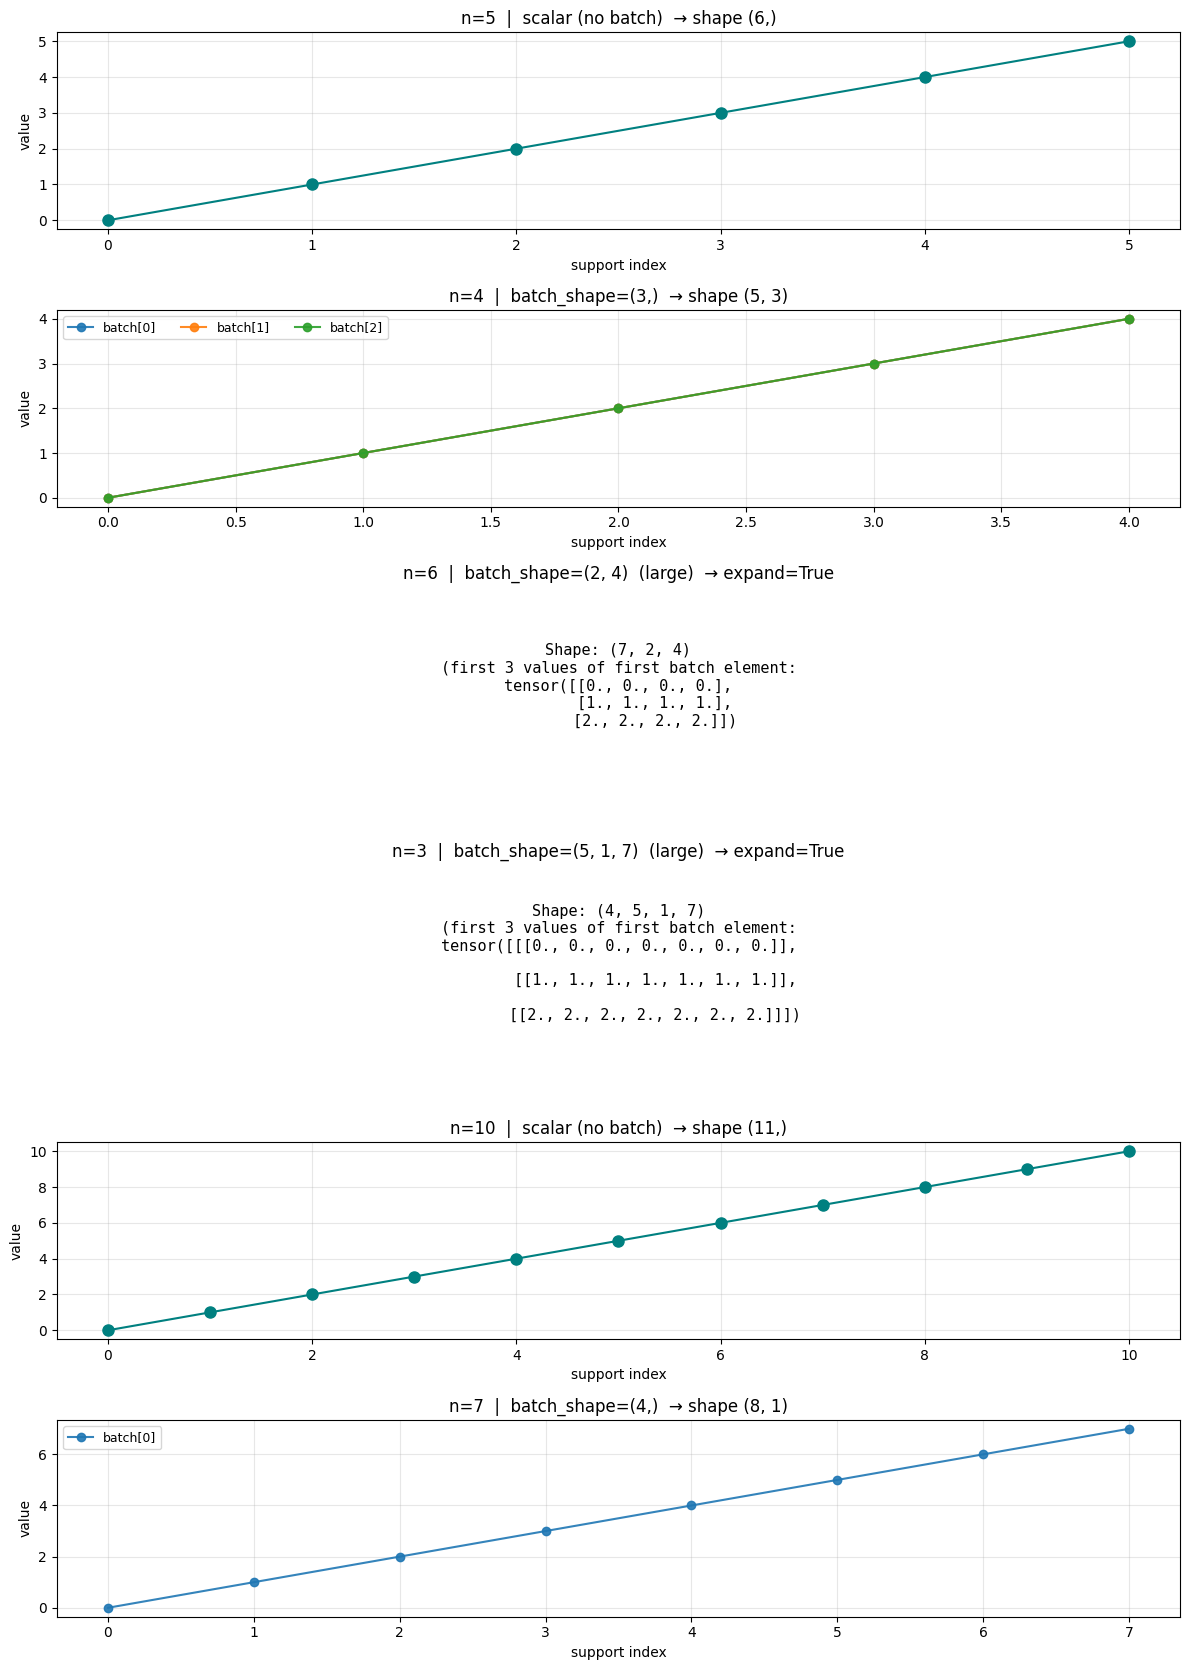


Support enumeration test cases

• n = 5   | batch_shape = ()                 | expand = True
  → shape = (6,)                          
  Values (first few batch elements):
tensor([0., 1., 2., 3., 4., 5.])
-----------------------------------------------------------------
• n = 4   | batch_shape = (3,)               | expand = True
  → shape = (5, 3)                        
  Values (first few batch elements):
tensor([[0., 0., 0.],
        [1., 1., 1.],
        [2., 2., 2.],
        [3., 3., 3.],
        [4., 4., 4.]])
-----------------------------------------------------------------
• n = 6   | batch_shape = (2, 4)             | expand = True
  → shape = (7, 2, 4)                     
  Values (first few batch elements):
tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[2., 2., 2., 2.],
         [2., 2., 2., 2.]],

        [[3., 3., 3., 3.],
         [3., 3., 3., 3.]],

        [[4., 4., 4., 4.],
         [4., 4.,

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np


def enumerate_support_demo(n_trials, batch_shape=(), expand=True, device='cpu'):
    """
    Simulate the enumerate_support behavior and show the resulting tensor shape + content
    """
    # Simulate class attributes
    class DummyDist:
        def __init__(self, n, batch_shape, device, dtype=torch.float32):
            self._num_trials = n
            self.batch_shape = batch_shape
            self._param = torch.tensor(0.5, device=device, dtype=dtype)  # dummy

    dist = DummyDist(n_trials, batch_shape, device=device)
    
    # The actual code
    n = dist._num_trials
    values = torch.arange(
        n + 1, dtype=dist._param.dtype, device=dist._param.device
    )
    values = values.view((-1,) + (1,) * len(dist.batch_shape))
    if expand:
        values = values.expand((-1,) + dist.batch_shape)
    
    return values


def plot_support_grid(cases):
    fig, axes = plt.subplots(len(cases), 1, figsize=(12, 2.8 * len(cases)), squeeze=False)
    axes = axes.flat
    
    for i, case in enumerate(cases):
        n = case["n"]
        batch = case["batch_shape"]
        expand = case.get("expand", True)
        
        supp = enumerate_support_demo(n, batch, expand=expand)
        
        ax = axes[i]
        if len(supp.shape) <= 2:
            # Small cases → show actual values
            if supp.dim() == 1:
                ax.plot(range(len(supp)), supp.numpy(), 'o-', color='teal', markersize=8)
                ax.set_title(f"n={n}  |  scalar (no batch)  → shape {tuple(supp.shape)}")
            else:
                for b in range(supp.shape[1]):
                    ax.plot(range(len(supp)), supp[:, b].numpy(), 'o-', 
                            label=f"batch[{b}]", alpha=0.9)
                ax.set_title(f"n={n}  |  batch_shape={batch}  → shape {tuple(supp.shape)}")
                ax.legend(ncol=5, fontsize=9)
        else:
            # Larger batch → just show shape & small preview
            ax.text(0.5, 0.5, f"Shape: {tuple(supp.shape)}\n(first 3 values of first batch element:\n{supp[:3, 0, ...]}",
                    ha='center', va='center', fontsize=11, family='monospace')
            ax.set_title(f"n={n}  |  batch_shape={batch}  (large)  → expand={expand}")
            ax.axis('off')
        
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("support index")
        ax.set_ylabel("value")
    
    plt.tight_layout()
    plt.show()
    
    # Also print summary
    print("\n" + "="*65)
    print("Support enumeration test cases")
    print("="*65 + "\n")
    for case in cases:
        supp = enumerate_support_demo(case["n"], case["batch_shape"], case.get("expand", True))
        print(f"• n = {case['n']:<3} | batch_shape = {str(case['batch_shape']):<18} | expand = {case.get('expand',True)}")
        print(f"  → shape = {str(tuple(supp.shape)):<30}")
        if supp.numel() <= 60:
            print("  Values (first few batch elements):")
            print(supp[:8])
        else:
            print("  (large tensor – showing shape & first 3×3 slice only)")
            print(supp[:3, :3, ...] if supp.dim() > 2 else supp[:3])
        print("-"*65)


# ─── Test cases ──────────────────────────────────────────────────────

test_cases = [
    {"n": 5,   "batch_shape": ()},
    {"n": 4,   "batch_shape": (3,)},
    {"n": 6,   "batch_shape": (2, 4)},
    {"n": 3,   "batch_shape": (5, 1, 7)},
    {"n": 10,  "batch_shape": (), "expand": False},
    {"n": 7,   "batch_shape": (4,), "expand": False},
]

plot_support_grid(test_cases)